In [1]:
import pandas as pd
import shap
shap.initjs()

In [2]:
import sys
sys.path.append("..")
from helper_functions.prep_data_function import prepare_train_test
X_train, X_test, y_train, y_test = prepare_train_test("../data/cab_rides_features.csv")
X_train

,cab_type,name,source,destination,time_of_day,demand_density,distance,rides_in_hour_at_source,bad_weather_score,is_raining,is_weekend,ride_hour,uber_lyft_price_ratio
0,Lyft,Lux Black XL,Boston University,Theatre District,late_night,low,3.03,9,0.311602,False,False,3,NaN
1,Uber,Black,South Station,Theatre District,late_night,low,1.30,11,0.319336,False,False,3,NaN
2,Lyft,Lyft,Northeastern University,Beacon Hill,late_night,low,2.43,4,0.321602,False,False,3,NaN
3,Uber,UberXL,Theatre District,Fenway,late_night,low,2.71,13,0.318420,False,False,3,2.755102
4,Uber,UberX,Theatre District,Fenway,late_night,low,2.71,13,0.318420,False,False,3,2.755102
...,...,...,...,...,...,...,...,...,...,...,...,...,...
510380,Lyft,Lux,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513
510379,Lyft,Lyft XL,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513
510376,Lyft,Lux Black,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513
510377,Lyft,Lyft,South Station,West End,evening,low,2.00,123,0.360612,False,True,17,0.802513


In [3]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1, 0.2],
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(n_estimators=300,enable_categorical=True,tree_method="hist",random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
)
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [4, 6]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_

In [4]:
grid_search.best_params_, grid_search.best_score_

({'learning_rate': 0.1, 'max_depth': 6}, np.float64(-0.20199240790077835))

In [5]:
val_cut = int(len(X_train) * 0.8)
X_tr, X_val = X_train.iloc[:val_cut], X_train.iloc[val_cut:]
y_tr, y_val = y_train.iloc[:val_cut], y_train.iloc[val_cut:]
X_tr.shape, X_val.shape

((408305, 13), (102077, 13))

In [6]:
model = xgb.XGBRegressor(
    **grid_search.best_params_,
    n_estimators=1000,
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    early_stopping_rounds=20,
    eval_metric="rmse",
)
model.fit(X_tr,y_tr,eval_set=[(X_val,y_val)],verbose=False)
model.best_iteration

451

In [7]:
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_true=y_test,y_pred=y_pred)

0.5618393986210306

In [8]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

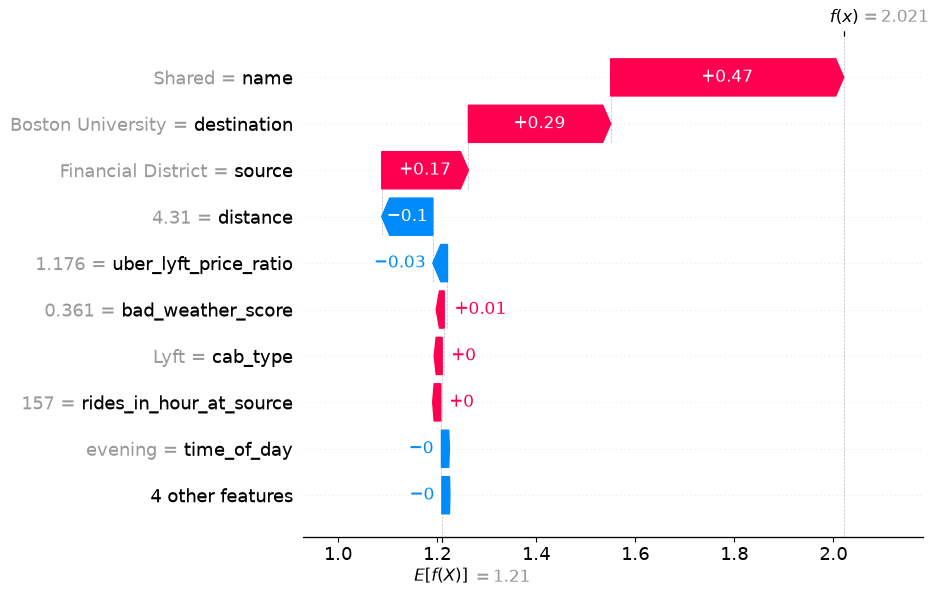

In [9]:
shap.plots.waterfall(shap_values[0])

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(y_true=y_test,y_pred=y_pred)**0.5
mae = mean_absolute_error(y_true=y_test,y_pred=y_pred)
rmse, mae

(0.19935859829698757, 0.11925964567635985)

In [11]:
y_train_pred = model.predict(X_train)
r2_score(y_true=y_train,y_pred=y_train_pred)

0.6259113751036816

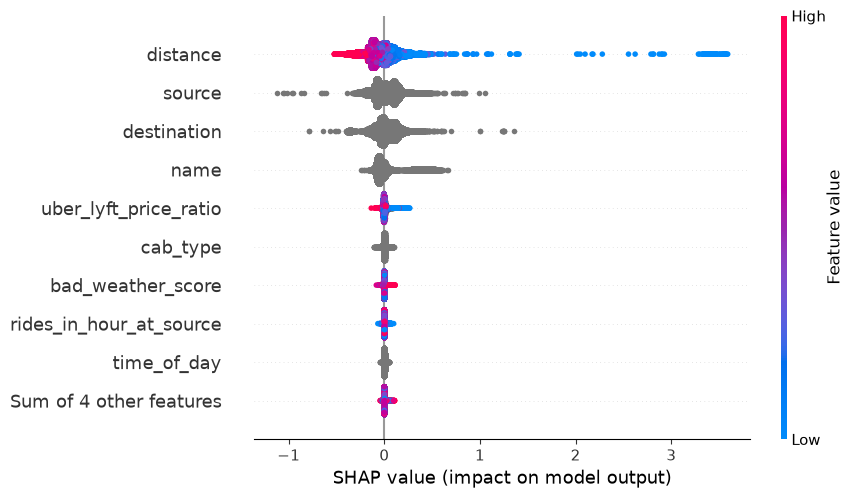

In [12]:
shap.plots.beeswarm(shap_values)